# LIBRAIRIES

In [1]:
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from nucleo.io.reading import checking_parameters
from nucleo.io.reading import reading_one_parquet
from nucleo.io.reading import finding_one_parquet
from nucleo.io.reading import reading_all_parquet

# DATA : Root

Need to analyse new data because ryu data closer to 100 than 90

In [2]:
root_data = "/home/nicolas/Documents/Workspace/nucleo/outputs/FACT__PSMN__2026-04-16"

# DATA : Single

In [3]:
params_single = {
    "algo"      : "2S",
    "fact"      : True,
    "mode"      : "passfull",
    "dstr"      : False, 
    "land"      : "homogen",
    "s"         : 35,
    "l"         : 35,
    "bpmin"     : 0,
    "mu"        : 150,
    "theta"     : 100,
    "alphar"    : 0.00,
    "Kp"        : 0.00,
    "Kz"        : 0.00
}

df_single = finding_one_parquet(root_data, params_single)
print(df_single)

Scanning 105240 parquet files...
Found in : ['/home/nicolas/Documents/Workspace/nucleo/outputs/FACT__PSMN__2026-04-16/nucleo__passfull__8/algo=2S__fact=True__mode=passfull__dstr=False__land=homogen__s=35__l=35__bpmin=0__mu=150__theta=100__rcapt=1.7e-01__rrest=1.7e-01__alphac=6.0e-01__alphad=0.0e+00__alphar=0.0e+00__Ktot=1.0e+00__Kp=0.0e+00__Kz=0.0e+00__nt=1.0e+04__/algo=2S__fact=True__mode=passfull__dstr=False__land=homogen__s=35__l=35__bpmin=0__mu=150__theta=100__rcapt=1.7e-01__rrest=1.7e-01__alphac=6.0e-01__alphad=0.0e+00__alphar=0.0e+00__Ktot=1.0e+00__Kp=0.0e+00__Kz=0.0e+00__nt=1.0e+04__.parquet']
shape: (1, 93)
┌──────┬──────┬──────────┬───────┬───┬─────────────┬──────────────────────┬───────────┬────────────┐
│ algo ┆ fact ┆ mode     ┆ dstr  ┆ … ┆ xt_over_t   ┆ G                    ┆ bound_low ┆ bound_high │
│ ---  ┆ ---  ┆ ---      ┆ ---   ┆   ┆ ---         ┆ ---                  ┆ ---       ┆ ---        │
│ str  ┆ bool ┆ str      ┆ bool  ┆   ┆ list[f64]   ┆ list[f64]            

In [ ]:
def plot_df_main_info(df: pl.DataFrame, title: str = "") -> None:
    fig, (ax1, ax2, ax3) = plt.subplots(ncols=3, nrows=1, figsize=(24, 6))
    
    if title:
        fig.suptitle(title, fontsize=14)

    # --- Trajectories ---
    ax1.set_title("Trajectories")
    x1 = df["t_matrix"][0].to_numpy()
    y1 = df["x_matrix"][0].to_numpy()
    for i in range(10):
        ax1.plot(x1[i], y1[i], drawstyle="steps-mid")
    ax1.grid(True, which="both")

    # --- Mean Trajectory ---
    ax2.set_title("Mean Trajectory")
    x2 = df["times"][0].to_numpy()
    y2 = df["results_mean"][0].to_numpy()
    ax2.plot(x2, y2)
    ax2.grid(True, which="both")

    # --- Speed Distribution ---
    ax3.set_title("Speed Distribution")
    x3 = df["vi_points"][0].to_numpy()
    y3 = df["vi_distrib"][0].to_numpy()
    ax3.loglog(x3, y3)
    ax3.grid(True, which="both")

    plt.tight_layout()
    plt.show()

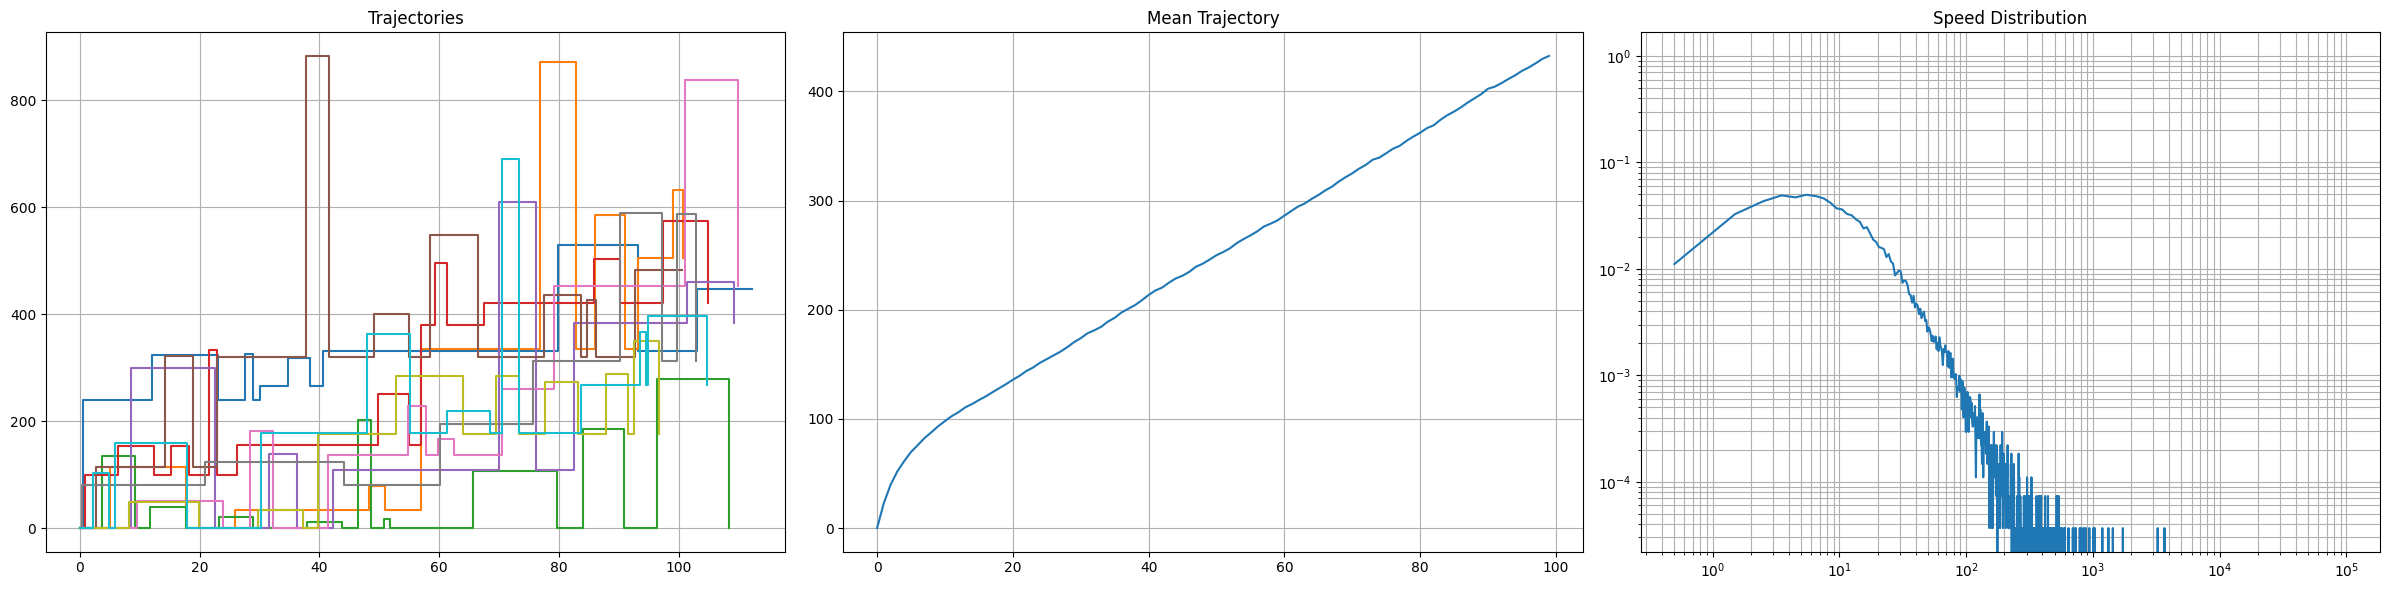

In [4]:
fig, (ax1, ax2, ax3) = plt.subplots(ncols=3, nrows=1, figsize=(24,6))

ax1.set_title("Trajectories")
x1 = df_single["t_matrix"][0].to_numpy()
y1 = df_single["x_matrix"][0].to_numpy()
for i in range(0,10):
    ax1.plot(x1[i], y1[i], drawstyle="steps-mid")
ax1.grid(True, which="both")

ax2.set_title("Mean Trajectory")
x2 = df_single["times"][0].to_numpy()
y2 = df_single["results_mean"][0].to_numpy()
ax2.plot(x2, y2)
ax2.grid(True, which="both")

ax3.set_title("Speed Distribution")
x3 = df_single["vi_points"][0].to_numpy()
y3 = df_single["vi_distrib"][0].to_numpy()
ax3.plot(x3, y3)
ax3.loglog(True)
ax3.grid(True, which="both")


plt.tight_layout()
plt.show()

# DATA : Verification from without any remodelling

Regarder tout ça après avoir récupéré les résultats pour les simulations avec destroy dans les paramètres

In [12]:
# Reading
root_test = "/home/nicolas/Documents/Workspace/nucleo/outputs/FACT__PSMN__2026-04-16/" \
            "nucleo__passfull__8/algo=2S__fact=True__mode=passfull__dstr=False__land=homogen__s=35__l=35__bpmin=0__mu=150__theta=100__" \
            "rcapt=1.7e-01__rrest=1.7e-01__alphac=6.0e-01__alphad=0.0e+00__alphar=0.0e+00__Ktot=1.0e+00__Kp=0.0e+00__Kz=2.0e-01__nt=1.0e+04__"
df_test = reading_one_parquet(root_test)

# Printing
print(df_test.columns)

['algo', 'fact', 'mode', 'dstr', 'landscape', 's', 'l', 'bpmin', 'mu', 'theta', 'alphaf', 'alphao', 'beta', 'rcapt', 'rrest', 'alphac', 'alphad', 'alphar', 'Ktot', 'Kp', 'Kz', 'c_linker', 'c_nucleo', 'Lmin', 'Lmax', 'bps', 'origin', 'tmax', 'dt', 'times', 'binx', 'bint', 'nt', 's_mean', 'l_mean', 'alpha_mean_a', 'alpha_mean_v', 'alpha_mean_c', 'v_mean', 'v_med', 'v_mean_th', 'v_mean_th_eff', 'vf', 'Cf', 'wf', 'vf_std', 'Cf_std', 'wf_std', 'vi_mean', 'vi_med', 'vi_mp', 'vc_mean', 'vc_med', 'vc_mp', 't_matrix', 'x_matrix', 'results', 'obstacles', 's_points', 's_distrib', 'l_points', 'l_distrib', 'l_view', 'p', 'results_mean', 'results_med', 'results_std', 'pos_hist', 'xbj_points', 'xbj_distrib', 'tbj_points', 'tbj_distrib', 'fpt_distrib', 'fpt_number', 'dx_points', 'dx_distrib', 'dx_mean', 'dx_med', 'dx_mp', 'dt_points', 'dt_distrib', 'dt_mean', 'dt_med', 'dt_mp', 'vi_points', 'vi_distrib', 'vc_points', 'vc_distrib', 'alpha0', 'xt_over_t', 'G', 'bound_low', 'bound_high']


In [ ]:
# Finding Verification File
root_verif = "/home/nicolas/Documents/Workspace/nucleo/outputs/NUCLEO__PSMN__2026-04-17"
params_verif = {
    **params_single,
    "algo"      : "1S",
    "fact"      : False,
    "mode"      : "none",
    "s"         : 150,
    "l"         : 150
}

# Checking Parameters
print(params_single)
print(params_verif)

# Checking Data
df_verif = finding_one_parquet(root_verif, params_verif)
print(df_verif)
print(df_verif.columns)

{'algo': '2S', 'fact': True, 'mode': 'passfull', 'dstr': False, 'land': 'homogen', 's': 35, 'l': 35, 'bpmin': 0, 'mu': 150, 'theta': 100, 'alphar': 0.0, 'Kp': 0.0, 'Kz': 0.0}
{'algo': '1S', 'fact': False, 'mode': 'none', 'dstr': False, 'land': 'homogen', 's': 150, 'l': 150, 'bpmin': 0, 'mu': 150, 'theta': 100, 'alphar': 0.0, 'Kp': 0.0, 'Kz': 0.0}


In [ ]:
plot_df_main_info(df_single, title="Single : 2 Steps + FACT")
plot_df_main_info(df_verif,  title="Verif : 1 Step +  NO FACT")

# DATA : Multi

In [ ]:
# The file
df_all = reading_all_parquet(root_data)
print(df_all.shape)
print(df_all.columns)

# The parameters
params_sim = checking_parameters(df_all)
# print(params_sim)

# The unique values of parameters
for param in params_sim:
    param_value = np.unique(df_all[param])
    print(f"{param} : {param_value}")

# Adding R = K * alphar
df_all = (
    df_all.clone()
    .with_columns((pl.col("Kp") * pl.col("alphar")).alias("R"))
)
print(df_all.shape) 

/home/nicolas/Documents/Workspace/nucleo/src/nucleo/io/reading.py:141: PerformanceWarning: Resolving the schema of a LazyFrame is a potentially expensive operation. Use `LazyFrame.collect_schema()` to get the schema without this warning.
  cols = _scalar_column_names(lf.schema)


(8712, 61)
['algorithm', 'fact', 'factmode', 'destroy', 'landscape', 's', 'l', 'bpmin', 'mu', 'theta', 'alphaf', 'alphao', 'beta', 'alphac', 'alphad', 'rtot_capt', 'rtot_rest', 'alphar', 'K', 'ktot', 'kB', 'kU', 'c_linker', 'c_nucleo', 'Lmin', 'Lmax', 'bps', 'origin', 'tmax', 'dt', 'binx', 'bint', 'nt', 's_mean', 'l_mean', 'alpha_mean_v', 'alpha_mean_c', 'v_mean', 'v_med', 'v_mean_th', 'v_mean_th_eff', 'vf', 'Cf', 'wf', 'vf_std', 'Cf_std', 'wf_std', 'vi_mean', 'vi_med', 'vi_mp', 'vc_mean', 'vc_med', 'dx_mean', 'dx_med', 'dx_mp', 'dt_mean', 'dt_med', 'dt_mp', 'alpha0', 'bound_low', 'bound_high']
algorithm : ['two_steps']
fact : [ True]
factmode : ['active_full' 'active_memory' 'passive_full' 'passive_memory']
destroy : [False]
landscape : ['homogeneous' 'periodic' 'random']
s : [35]
l : [ 10  35 100]
bpmin : [0]
mu : [150]
theta : [20 90]
alphar : [0.  0.1 0.2 0.3 0.4 0.5 0.6 0.7 0.8 0.9 1. ]
K : [0.  0.1 0.2 0.3 0.4 0.5 0.6 0.7 0.8 0.9 1. ]
alphaf : [1.]
alphao : [0.]
beta : [0.]
alpha

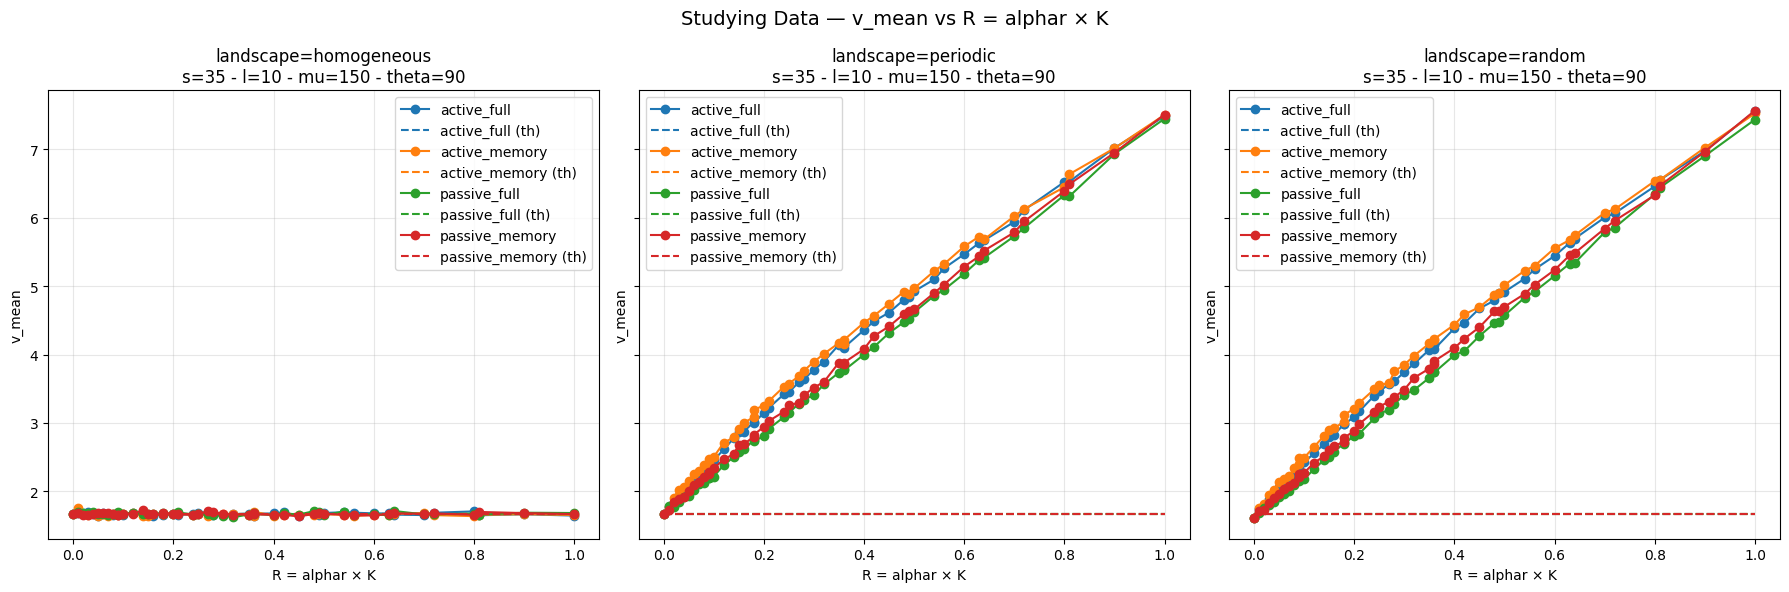

In [ ]:

# Parameters Fixed (sans landscape, qui devient l'axe des panels)
s     = 35
l     = 10
bpmin = 0
mu    = 150
theta = 100

params_fixed = {
    "fact"      : True,
    "algorithm" : "two_steps",
    "s"         : s,
    "l"         : l,
    "bpmin"     : bpmin,
    "mu"        : mu,
    "theta"     : theta,
}

# Parameters Non Fixed
alphars = params_sim["alphar"]
modes   = params_sim["mode"]
lands   = params_sim["lands"]

def filter_df(df: pl.DataFrame, params: dict) -> pl.DataFrame:
    """Filtre df sur les clés/valeurs de params, en ignorant les valeurs None."""
    filters = [pl.col(k) == v for k, v in params.items() if v is not None]
    return df.filter(pl.all_horizontal(filters)) if filters else df

df_filtered = filter_df(df_all, params_fixed)

# ── Plot ──────────────────────────────────────────────────────────────────────
n_landscapes = len(lands)
fig, axes = plt.subplots(ncols=n_landscapes, nrows=1, figsize=(6 * n_landscapes, 6), sharey=True)

if n_landscapes == 1:
    axes = [axes]

plt.suptitle("Studying Data — v_mean vs R = alphar × K", fontsize=14)

def make_title(landscape: str, params: dict) -> str:
    keys = ["s", "l", "mu", "theta"]
    parts = [f"{k}={params[k]}" for k in keys if k in params]
    return f"landscape={landscape}\n" + " - ".join(parts)

for ax, landscape in zip(axes, lands):
    df_land = df_filtered.filter(pl.col("landscape") == landscape)

    ax.set_title(make_title(landscape, params_fixed))
    
    for mode in modes:
            df_solo = (
                df_land
                .filter(pl.col("mode") == mode)
                .group_by("R")
                .agg([
                    pl.col("v_mean").mean(),
                    pl.col("v_mean_th").mean(),
                ])
                .sort("R")
            )
            R      = df_solo["R"].to_numpy()
            v      = df_solo["v_mean"].to_numpy()
            v_th   = df_solo["v_mean_th"].to_numpy()

            line, = ax.plot(R, v,    label=mode, marker="o")
            ax.plot(        R, v_th, label=f"{mode} (th)",
                    linestyle="--", color=line.get_color(), marker="")

    ax.set_xlabel("R = alphar × K")
    ax.set_ylabel("v_mean")
    ax.grid(True, which="both", alpha=0.30)
    ax.legend()

plt.tight_layout()
plt.show()

In [ ]:
# --- Colonne R + filtres ---
df_work = (
    df_all.clone()
    .with_columns((pl.col("K") * pl.col("alphar")).alias("R"))
    .filter(
        (pl.col("l")     == l)     &
        (pl.col("mu")    == mu)    &
        (pl.col("theta") == theta)
    )
)

# --- Moyenne de v_mean par (factmode, landscape, R) ---
df_agg = (
    df_work
    .group_by(["factmode", "landscape", "R"])
    .agg(pl.col("v_mean").mean())
    .sort(["factmode", "landscape", "R"])
)

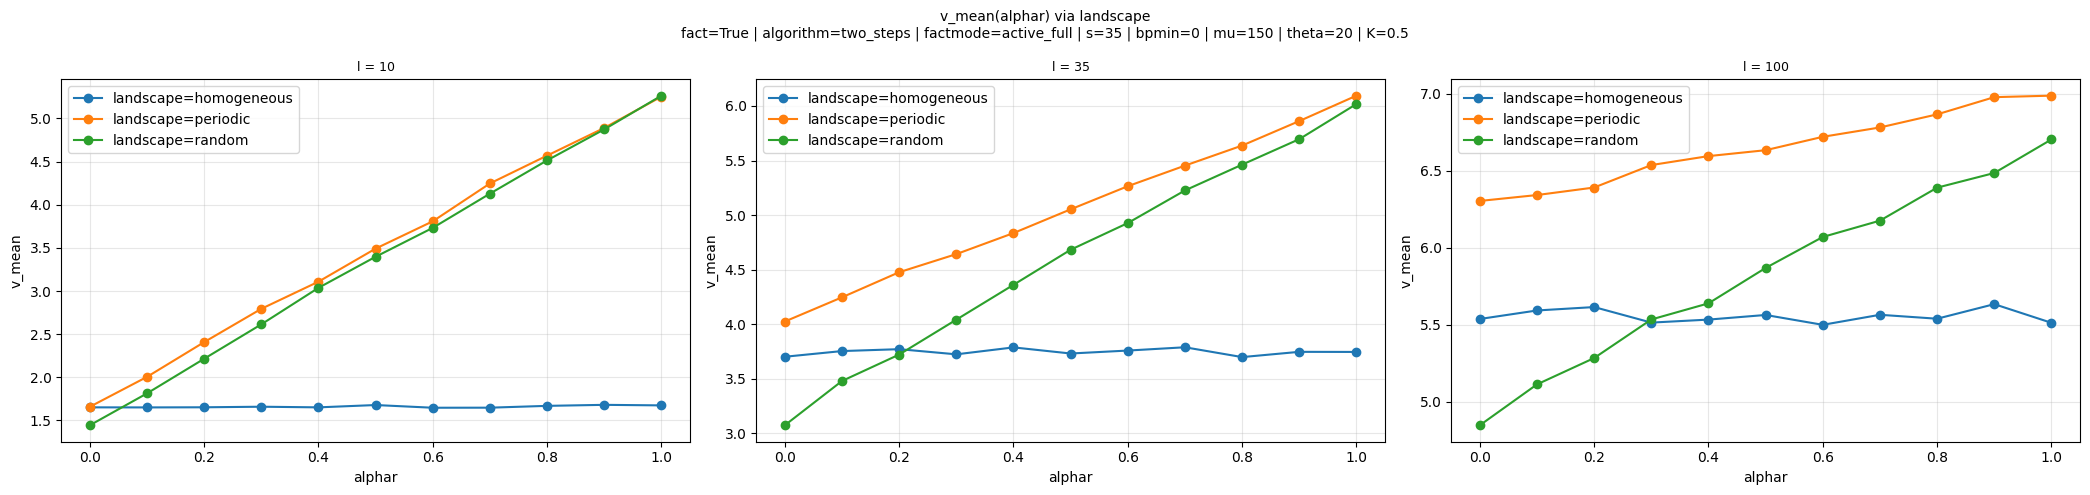

In [12]:
def plot_fact_data(
    df        : pl.DataFrame,
    x         : str,
    y         : str,
    param     : str,
    fixed     : dict = {},
    ax        : plt.Axes = None,
    title     : str = None,
    marker    : str = "o",
) -> plt.Axes:
    """
    Trace y(x) pour chaque valeur de `param`, les autres paramètres étant fixés.

    Args:
        df     : DataFrame source (df_all)
        x      : colonne pour l'axe X
        y      : colonne pour l'axe Y
        param  : colonne dont on fait varier les valeurs (une courbe par valeur)
        fixed  : dict {colonne: valeur} des paramètres à fixer via filtre
        ax     : axes matplotlib existant (sinon en crée un nouveau)
        title  : titre du graphique (auto-généré si None)
        marker : marqueur matplotlib
    """
    # Filtrage
    filters = [pl.col(k) == v for k, v in fixed.items() if v is not None]
    df_filtered = df.filter(pl.all_horizontal(filters)) if filters else df

    # Axe
    if ax is None:
        _, ax = plt.subplots(figsize=(7, 5))

    # Une courbe par valeur de param
    for val in sorted(df_filtered[param].unique().to_list()):
        df_solo = df_filtered.filter(pl.col(param) == val).sort(x)
        ax.plot(df_solo[x].to_numpy(), df_solo[y].to_numpy(), label=f"{param}={val}", marker=marker)

    # Titre auto si non fourni
    if title is None:
        fixed_str = " | ".join(f"{k}={v}" for k, v in fixed.items() if v is not None)
        title = f"{y}({x})  —  par {param}" + (f"\n{fixed_str}" if fixed_str else "")

    ax.set_title(title, fontsize=9)
    ax.set_xlabel(x)
    ax.set_ylabel(y)
    ax.grid(True, which="both", alpha=0.30)
    ax.legend()

    return ax


# Multi
x     = "alphar"
y     = "v_mean"
param = "landscape"
vary  = "l"

ls = sorted(df_all[vary].unique().to_list())
fig, axes = plt.subplots(ncols=len(ls), nrows=1, figsize=(7*len(ls), 5))

fixed_base = {
    "fact"      : True,
    "algorithm" : "two_steps",
    "factmode"  : "active_full",
    "s"         : 35,
    "bpmin"     : 0,
    "mu"        : 150,
    "theta"     : 20,
    "K"         : 0.50,
}

for ax, l_val in zip(axes, ls):
    plot_fact_data(
        df    = df_all,
        x     = x,
        y     = y,
        param = param,
        fixed = {**fixed_base, "l": l_val},
        ax    = ax,
        title = f"l = {l_val}",
    )

suptitle_str = " | ".join(f"{k}={v}" for k, v in fixed_base.items())
plt.suptitle(f"{y}({x}) via {param}\n{suptitle_str}", fontsize=10)
plt.tight_layout()
plt.show()

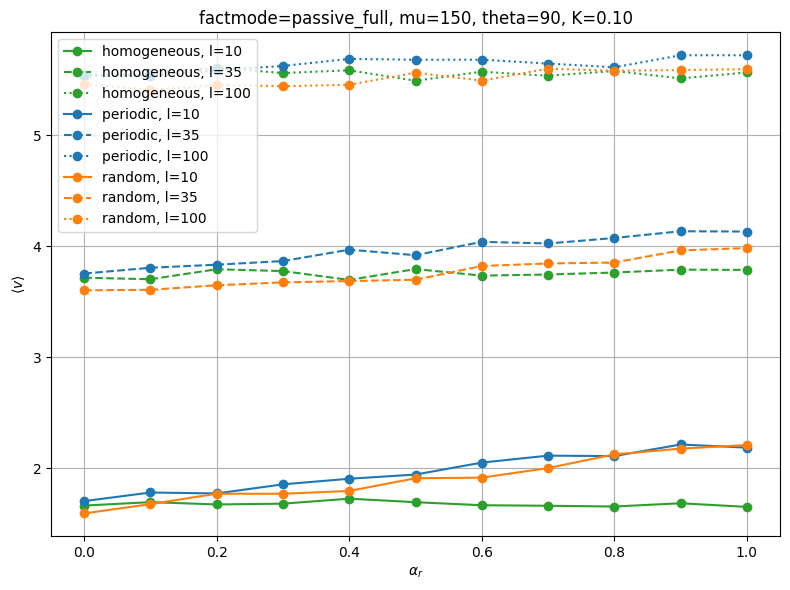

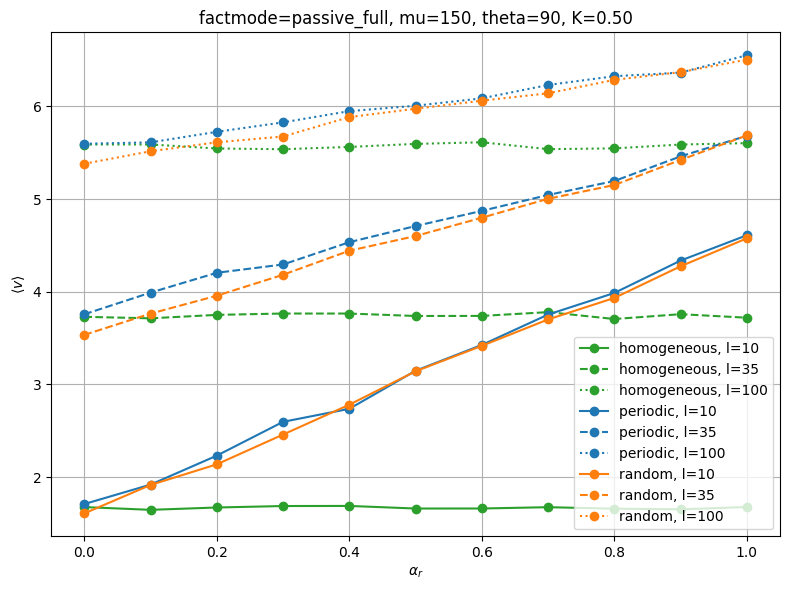

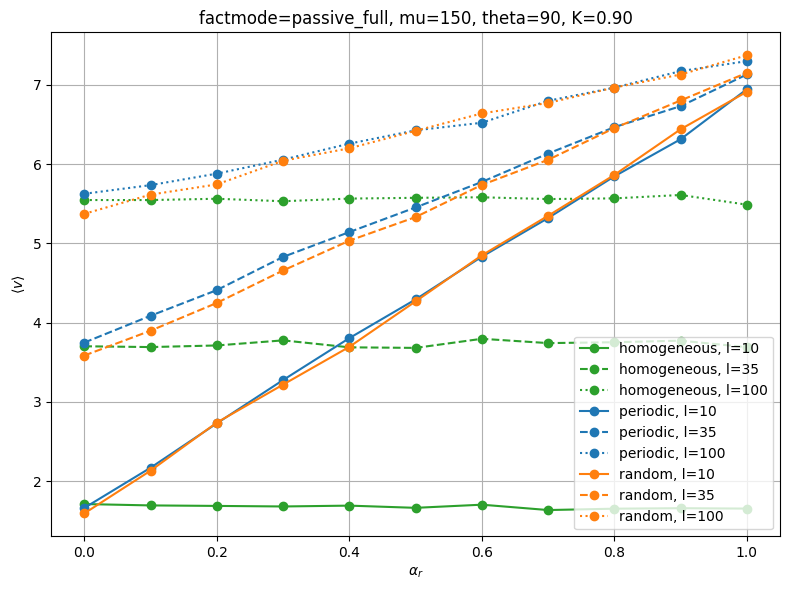

In [13]:
from itertools import product

# Couleurs par landscape
landscape_colors = {
    "periodic"    : "tab:blue",
    "random"      : "tab:orange",
    "homogeneous" : "tab:green",
}

# Styles par l (ordonnés)
ls_sorted  = np.sort(ls)
linestyles = {
    ls_sorted[0]: "-",
    ls_sorted[1]: "--",
    ls_sorted[2]: ":",
}

def plot_vmean_vs_alphar(df_all, value, factmode, K, title):
    plt.figure(figsize=(8, 6))
    plt.title(title)

    for landscape, l in product(landscapes, ls):
        df_data = df_all.filter(
            (pl.col("factmode")  == factmode) &
            (pl.col("landscape") == landscape) &
            (pl.col("l")         == l)         &
            (pl.col("mu")        == mu) &
            (pl.col("theta")     == theta) &
            (pl.col("K").is_close(K))
        )
        if df_data.height == 0:
            continue

        alphar  = df_data["alphar"].to_numpy()
        to_plot = df_data[value].to_numpy()

        plt.plot(
            alphar, to_plot,
            color     = landscape_colors[landscape],
            linestyle = linestyles[l],
            marker    = "o",
            label     = f"{landscape}, l={l}",
        )

    plt.xlabel(r"$\alpha_r$")
    plt.ylabel(r"$\langle v \rangle$")
    # plt.ylim([-1, 10])
    plt.grid(True)
    plt.legend(frameon=True)
    plt.tight_layout()
    plt.show()

value = "v_mean"
factmode = "passive_full"
plot_vmean_vs_alphar(df_all, value=value, factmode=factmode, K=0.10, title=f"factmode={factmode}, mu={mu}, theta={theta}, K=0.10")
plot_vmean_vs_alphar(df_all, value=value, factmode=factmode, K=0.50, title=f"factmode={factmode}, mu={mu}, theta={theta}, K=0.50")
plot_vmean_vs_alphar(df_all, value=value, factmode=factmode, K=0.90, title=f"factmode={factmode}, mu={mu}, theta={theta}, K=0.90")

# DATA : Heatmaps

['algorithm', 'fact', 'factmode', 'destroy', 'landscape', 's', 'l', 'bpmin', 'mu', 'theta', 'alphaf', 'alphao', 'beta', 'alphac', 'alphad', 'rtot_capt', 'rtot_rest', 'alphar', 'K', 'ktot', 'kB', 'kU', 'c_linker', 'c_nucleo', 'Lmin', 'Lmax', 'bps', 'origin', 'tmax', 'dt', 'binx', 'bint', 'nt', 's_mean', 'l_mean', 'alpha_mean_v', 'alpha_mean_c', 'v_mean', 'v_med', 'v_mean_th', 'v_mean_th_eff', 'vf', 'Cf', 'wf', 'vf_std', 'Cf_std', 'wf_std', 'vi_mean', 'vi_med', 'vi_mp', 'vc_mean', 'vc_med', 'dx_mean', 'dx_med', 'dx_mp', 'dt_mean', 'dt_med', 'dt_mp', 'alpha0', 'bound_low', 'bound_high']
{'algorithm': ['two_steps'], 'fact': [True], 'factmode': ['active_full', 'active_memory', 'passive_full', 'passive_memory'], 'destroy': [False], 'landscape': ['homogeneous', 'periodic', 'random'], 's': [35], 'l': [10, 35, 100], 'bpmin': [0], 'mu': [150], 'theta': [20, 90], 'alphar': [0.0, 0.1, 0.2, 0.30000000000000004, 0.4, 0.5, 0.6000000000000001, 0.7000000000000001, 0.8, 0.9, 1.0], 'K': [0.0, 0.1, 0.2, 0

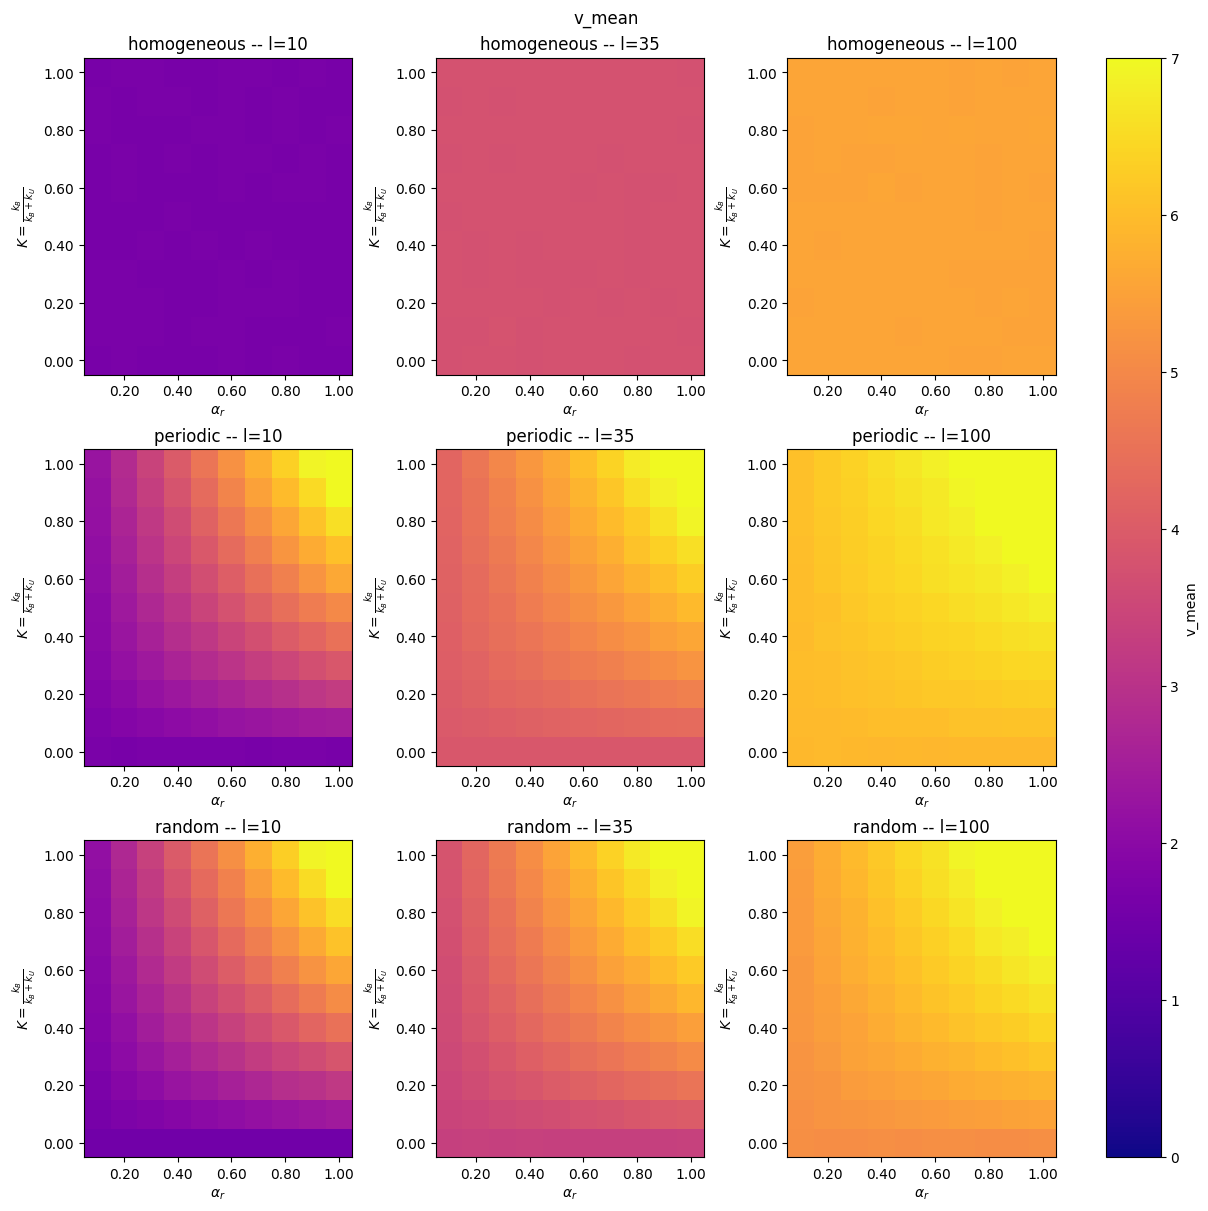

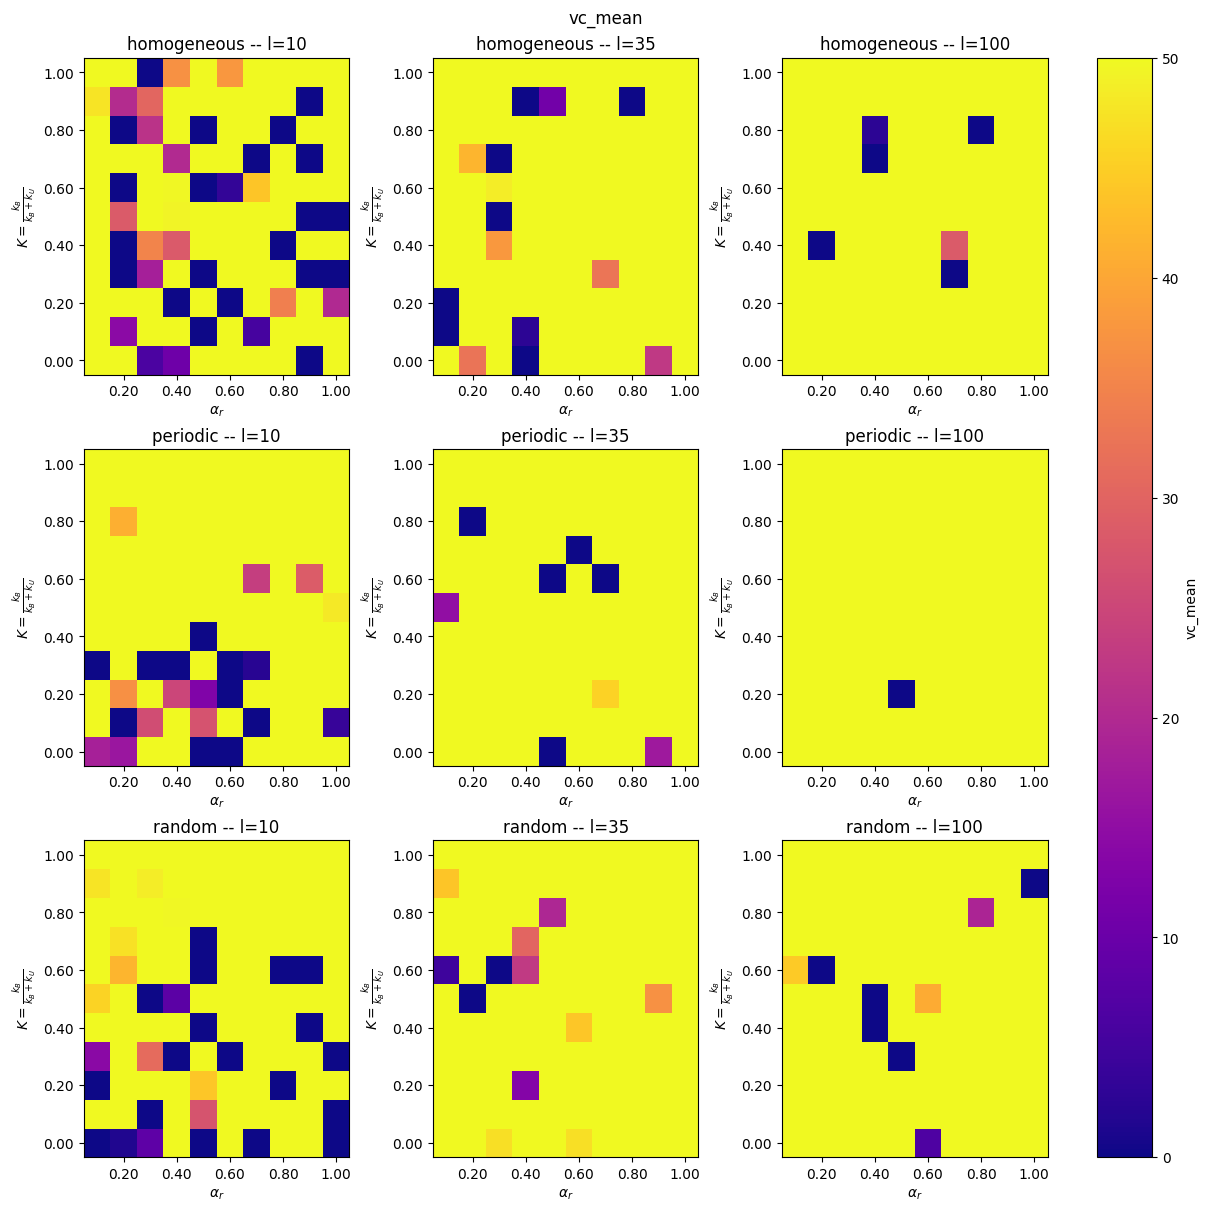

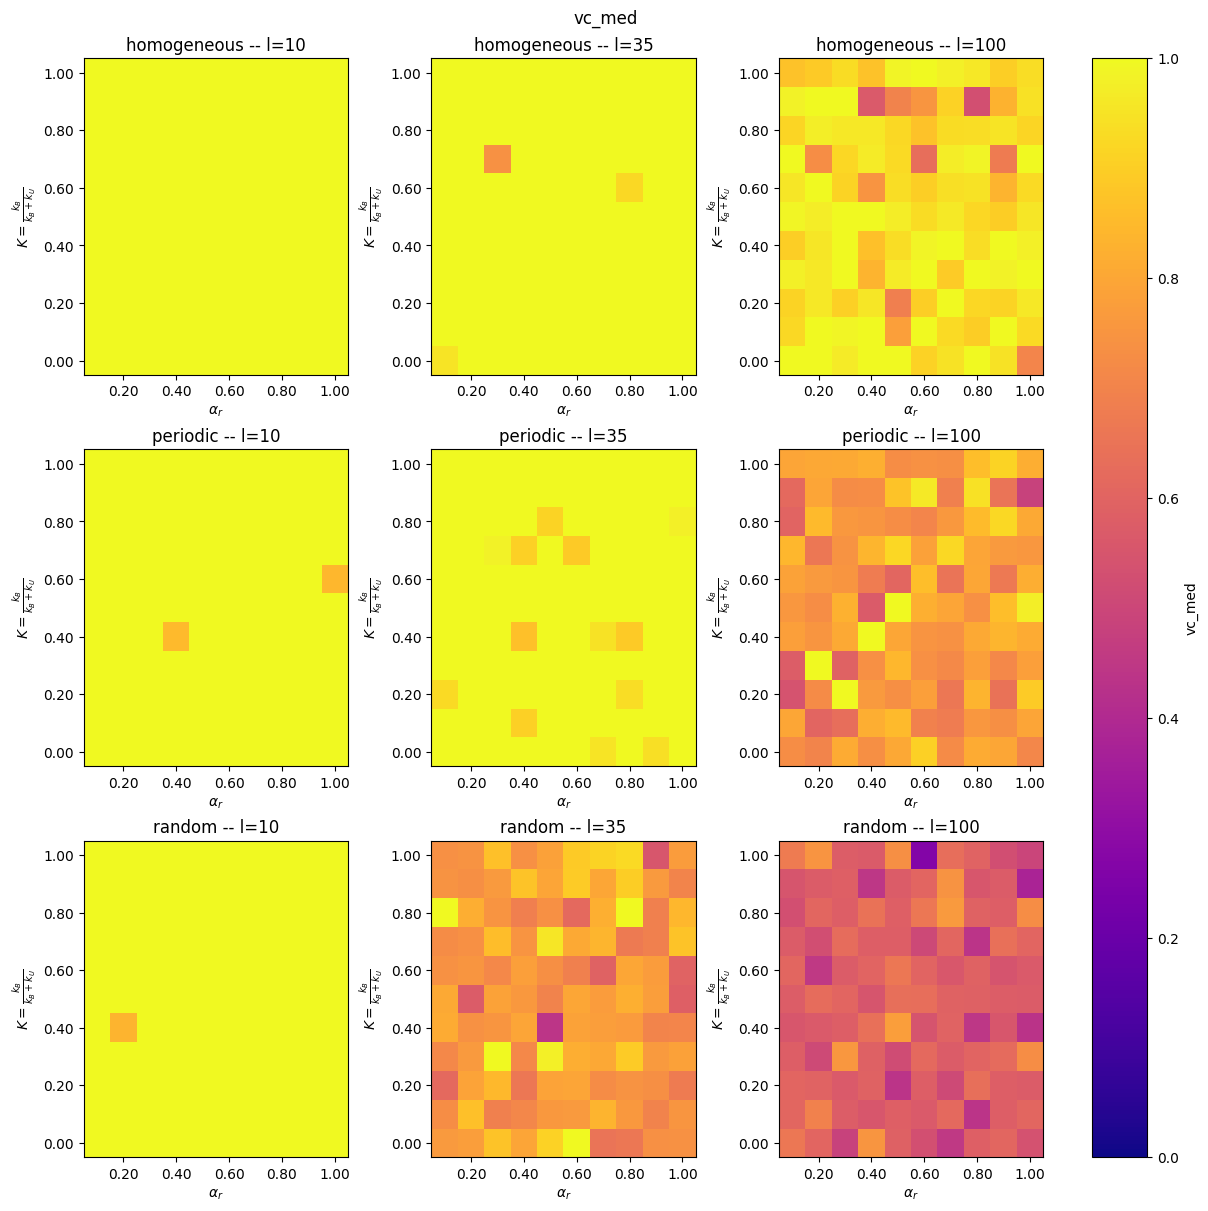

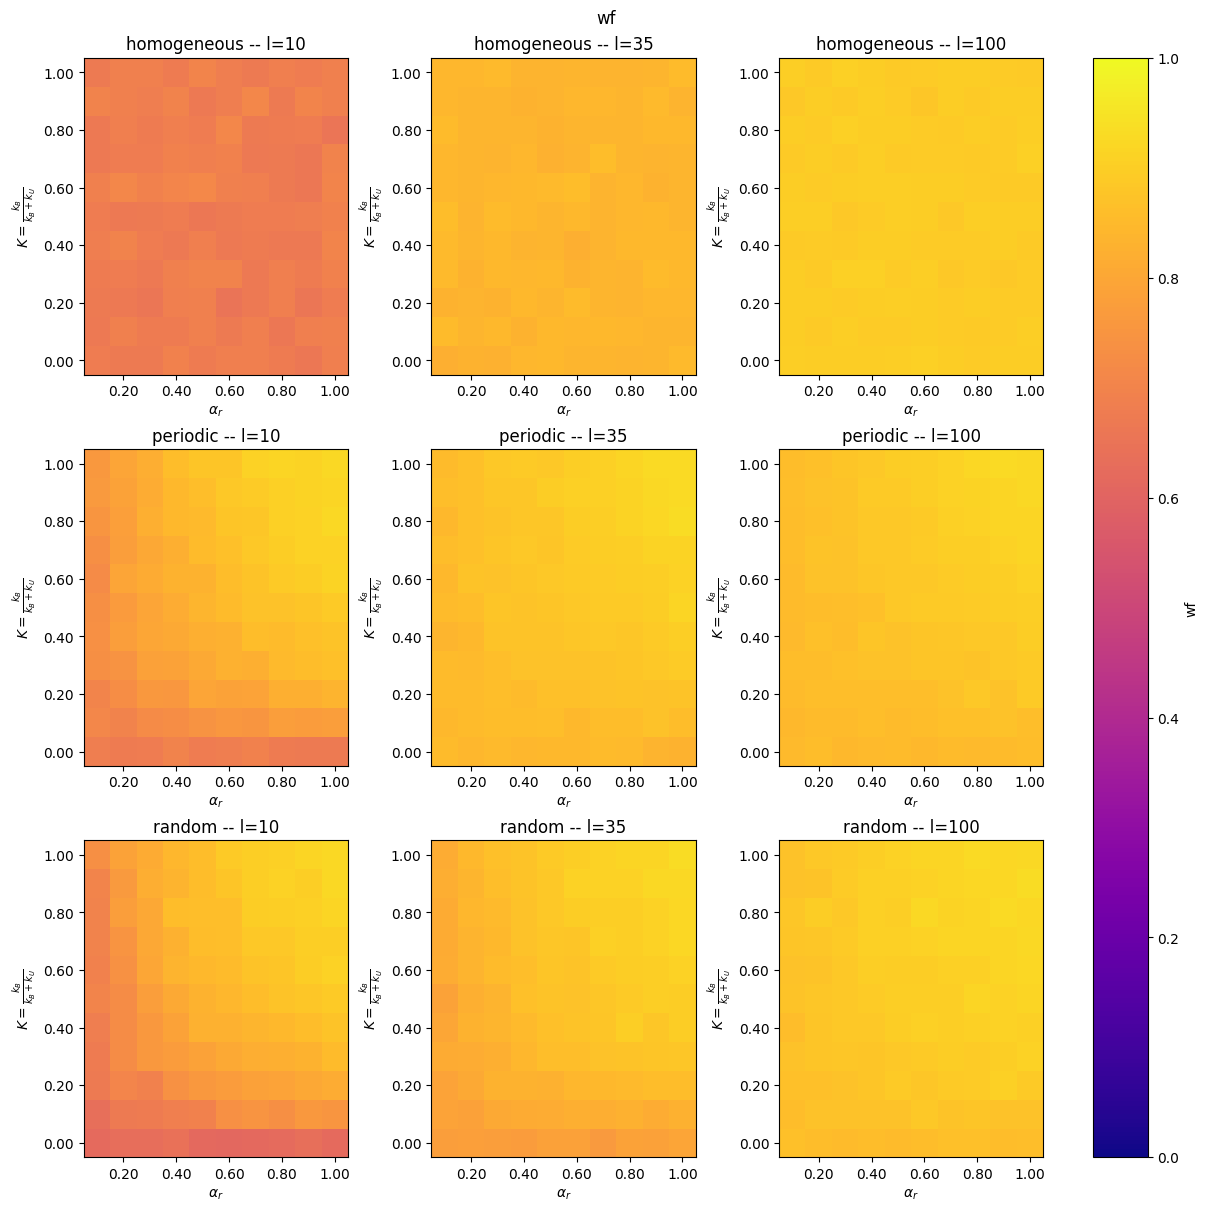

In [14]:
from itertools import product
import matplotlib.ticker as mticker
import matplotlib.pyplot as plt
import numpy as np
import polars as pl


def plot_single_heatmap(
    df: pl.DataFrame,
    landscape: str,
    l: int,
    value: str,
    ax,
    log_plot: bool = False,
    cmap: str = "plasma",
):
    """
    Plot a heatmap of `value` as a function of alphar (x) and K (y)
    for a given landscape and l.
    """
    # 1) Filtrage (alphar = 0 exclu)
    df_heat = (
        df.filter(
            (pl.col("landscape") == landscape) &
            (pl.col("l") == l) &
            (pl.col("alphar") > 0)
        )
        .select(["alphar", "K", value])
        .sort(["K", "alphar"])
    )

    if df_heat.height == 0:
        ax.set_title(f"{landscape} -- l={l}\n(no data)")
        return None

    # 2) Pivot 100% Polars → pas besoin de pandas
    pivot_pl = (
        df_heat
        .group_by(["K", "alphar"])
        .agg(pl.col(value).mean())
        .sort(["K", "alphar"])
        .pivot(on="alphar", index="K", values=value)
        .sort("K")
    )

    # Extraction des axes et de la grille
    Y = pivot_pl["K"].to_numpy()                          # lignes  (K)
    X = np.array(                                          # colonnes (alphar)
        sorted(float(c) for c in pivot_pl.columns if c != "K")
    )
    col_order = [str(x) for x in X]                       # ordre cohérent
    Z2D = pivot_pl.select(col_order).to_numpy().astype(float)

    X_grid, Y_grid = np.meshgrid(X, Y)

    # 3) Scale (lin / log)
    if log_plot:
        Z2D = np.log2(Z2D)
        vmin, vmax = -2, 2
    else:
        if value == "v_mean":
            vmin, vmax = 0, 7
        elif value == "vc_mean":
            vmin, vmax = 0, 50
        elif value == "vc_med":
            vmin, vmax = 0, 1
        elif value =="wf":
            vmin, vmax = 0, 1
        else:
            vmin, vmax = None, None

    # 4) Plot
    c = ax.pcolormesh(
        X_grid, Y_grid, Z2D,
        cmap=cmap,
        shading="auto",
        vmin=vmin,
        vmax=vmax,
    )
    ax.set_title(f"{landscape} -- l={l}")
    ax.set_xlabel(r"$\alpha_r$")
    ax.set_ylabel(r"$K = \frac{k_B}{k_B + k_U}$")
    ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))
    return c


def plot_heatmaps(df_all: pl.DataFrame, value: str, cmap: str = "plasma"):
    """Trace les heatmaps pour toutes les combinaisons (landscape, l)."""
    landscapes = sorted(df_all["landscape"].unique().to_list())
    ls = sorted(df_all["l"].unique().to_list())

    n_rows = len(landscapes)
    n_cols = len(ls)

    fig, axes = plt.subplots(
        n_rows, n_cols,
        figsize=(4 * n_cols, 4 * n_rows),
        constrained_layout=True,
    )
    axes_2d = np.array(axes).reshape(n_rows, n_cols)
    fig.suptitle(value)

    last_c = None
    for i, landscape in enumerate(landscapes):
        for j, l in enumerate(ls):
            c = plot_single_heatmap(df_all, landscape, l, value, axes_2d[i, j], cmap=cmap)
            if c is not None:
                last_c = c

    if last_c is not None:
        fig.colorbar(last_c, ax=axes_2d.ravel().tolist(), orientation='vertical', label=value)

    plt.show()


# ── Chargement ───────────────────────────────────────────────────────────────
df_all = reading_all_parquet(root_data)
print(df_all.columns)

params_sim = checking_parameters(df_all)
print(params_sim)

# ── Visualisations ───────────────────────────────────────────────────────────
for value in ["v_mean", "vc_mean", "vc_med", "wf"]:
    plot_heatmaps(df_all, value)

# ANALYSIS : v_mean(R = K * alphar)

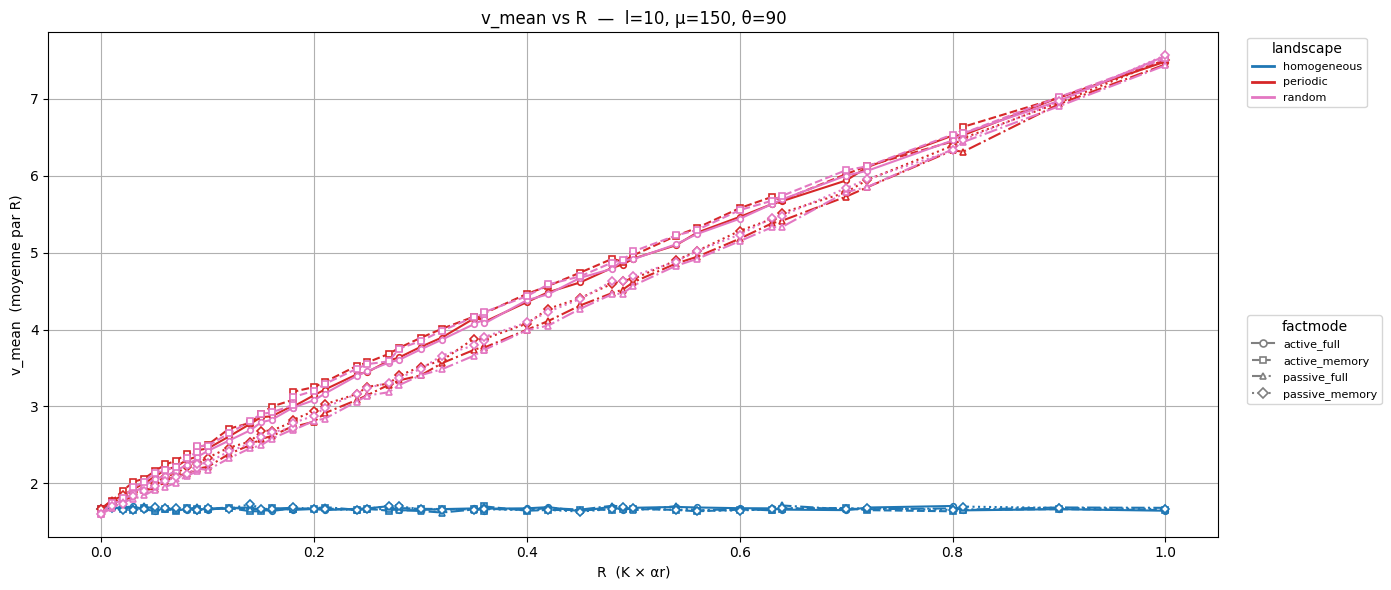

In [16]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.lines as mlines
import numpy as np
import polars as pl

# --- Filtres fixes ---
l     = 10
mu    = 150
theta = 90

# --- Colonne R + filtres ---
df_work = (
    df_all.clone()
    .with_columns((pl.col("K") * pl.col("alphar")).alias("R"))
    .filter(
        (pl.col("l")     == l)     &
        (pl.col("mu")    == mu)    &
        (pl.col("theta") == theta)
    )
)

# --- Moyenne de v_mean par (factmode, landscape, R) ---
df_agg = (
    df_work
    .group_by(["factmode", "landscape", "R"])
    .agg(pl.col("v_mean").mean())
    .sort(["factmode", "landscape", "R"])
)

# --- Valeurs uniques triées ---
landscapes = sorted(df_agg["landscape"].unique().to_list())
factmodes  = sorted(df_agg["factmode"].unique().to_list())

# --- Mappings visuels ---
colors     = {ls: cm.tab10(i / max(len(landscapes), 1))
              for i, ls in enumerate(landscapes)}

linestyles = ["-", "--", "-.", ":", (0, (3, 1, 1, 1))]
markers    = ["o", "s", "^", "D", "v", "P", "*"]

ls_style  = {fm: linestyles[i % len(linestyles)] for i, fm in enumerate(factmodes)}
ls_marker = {fm: markers[i % len(markers)]       for i, fm in enumerate(factmodes)}

# --- Tracé ---
fig, ax = plt.subplots(figsize=(14, 6))

for ls in landscapes:
    for fm in factmodes:
        sub = df_agg.filter(
            (pl.col("landscape") == ls) &
            (pl.col("factmode")  == fm)
        )
        if len(sub) == 0:
            continue
        ax.plot(
            sub["R"].to_numpy(),
            sub["v_mean"].to_numpy(),
            color=colors[ls],
            linestyle=ls_style[fm],
            marker=ls_marker[fm],
            markersize=4,
            markerfacecolor="white",
            markeredgewidth=1.2,
            linewidth=1.5,
        )

# --- Légende landscape (couleurs) ---
legend_landscape = [
    mlines.Line2D([], [], color=colors[ls], linewidth=2, label=str(ls))
    for ls in landscapes
]
leg1 = ax.legend(
    handles=legend_landscape,
    title="landscape",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    fontsize=8,
)
ax.add_artist(leg1)

# --- Légende factmode (marqueur + style de ligne) ---
legend_factmode = [
    mlines.Line2D(
        [], [],
        color="gray",
        linestyle=ls_style[fm],
        marker=ls_marker[fm],
        markersize=5,
        markerfacecolor="white",
        markeredgewidth=1.2,
        linewidth=1.5,
        label=str(fm),
    )
    for fm in factmodes
]
ax.legend(
    handles=legend_factmode,
    title="factmode",
    bbox_to_anchor=(1.02, 0.45),
    loc="upper left",
    fontsize=8,
)

ax.set_xlabel("R  (K × αr)")
ax.set_ylabel("v_mean  (moyenne par R)")
ax.set_title(f"v_mean vs R  —  l={l}, μ={mu}, θ={theta}")
ax.grid(True)
fig.tight_layout()
plt.show()

# ANALYSIS : K vs alphar

In [ ]:
# Je veux plotter : La croissance en fonction de K VS la croissance en fonction de alphar

# THEN :

In [37]:
# ── Calcul des colonnes de référence ─────────────────────────────────────────
# Vitesse de référence = v_mean pour landscape="homogeneous"
df_ref = (
    df_all
    .filter(pl.col("landscape") == "homogeneous")
    .select(["alphar", "K", "l", "v_mean"])
    .rename({"v_mean": "v_ref"})
)

# Join sur les clés communes
df_all = (
    df_all
    .join(df_ref, on=["alphar", "K", "l"], how="left")
    .with_columns([
        (pl.col("v_mean") - pl.col("v_ref")).alias("v_diff"),
        (pl.col("v_mean") / pl.col("v_ref")).alias("v_ratio"),
    ])
)

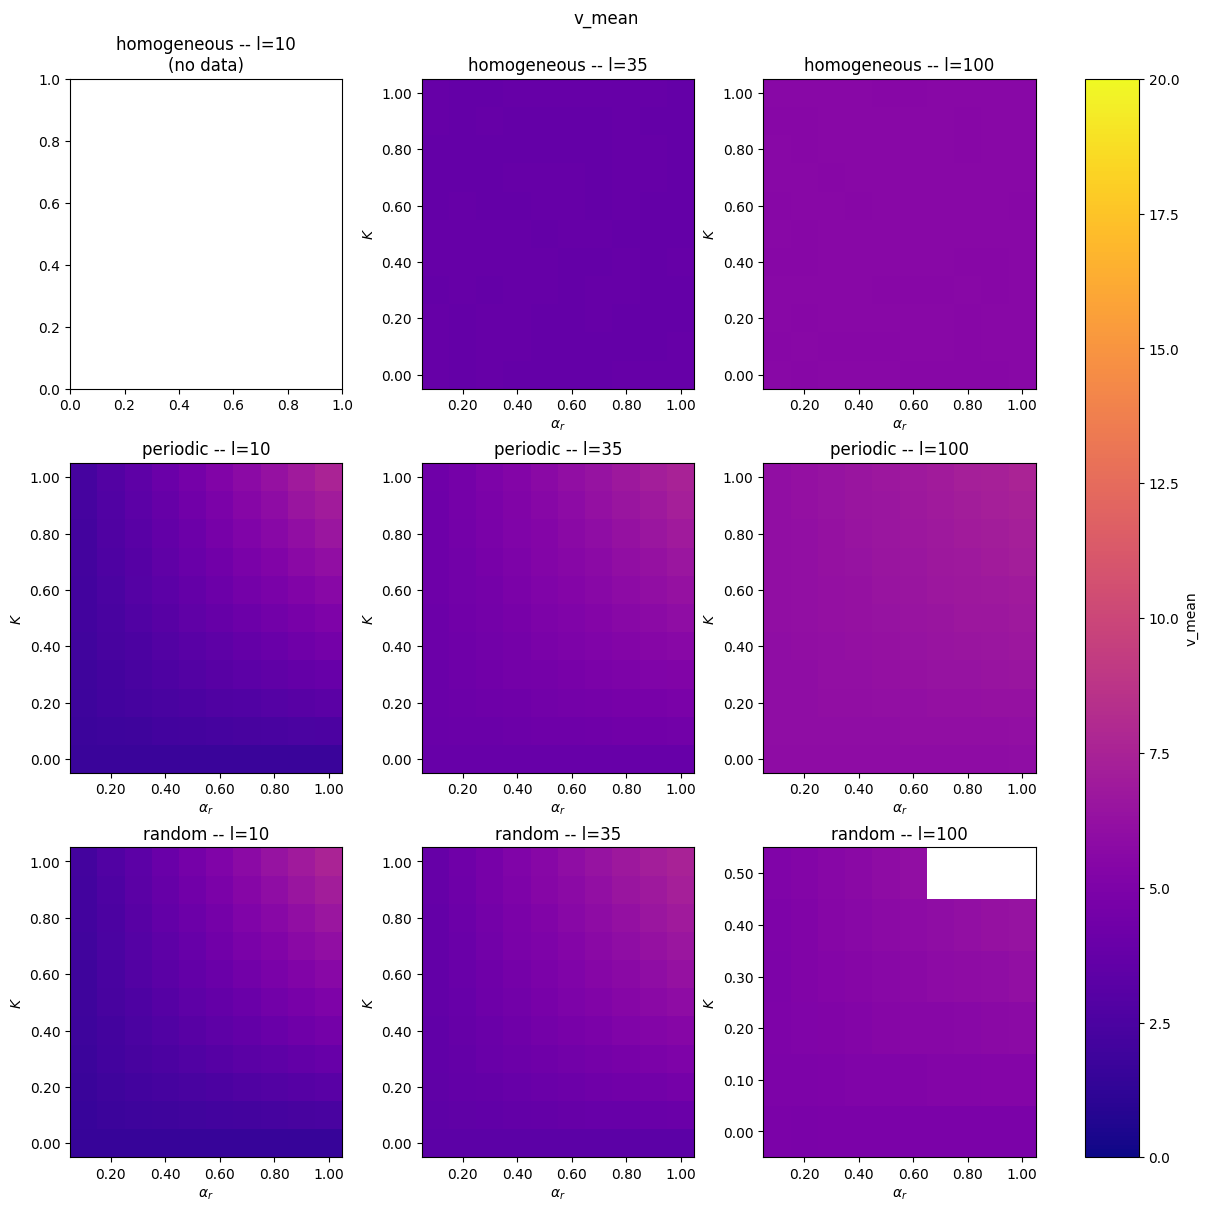

ColumnNotFoundError: unable to find column "v_diff"; valid columns: ["algorithm", "fact", "factmode", "landscape", "s", "l", "bpmin", "mu", "theta", "alphaf", "alphao", "beta", "lmbda", "alphad", "rtot_capt", "rtot_rest", "alphar", "K", "ktot", "kB", "kU", "c_linker", "c_nucleo", "Lmin", "Lmax", "bps", "origin", "tmax", "dt", "binx", "bint", "nt", "s_mean", "l_mean", "alpha_mean_v", "alpha_mean_c", "v_mean", "v_med", "v_mean_th", "v_mean_th_eff", "vf", "Cf", "wf", "vf_std", "Cf_std", "wf_std", "vi_mean", "vi_med", "vi_mp", "vc_mean", "vc_med", "dx_mean", "dx_med", "dx_mp", "dt_mean", "dt_med", "dt_mp", "alpha0", "bound_low", "bound_high"]

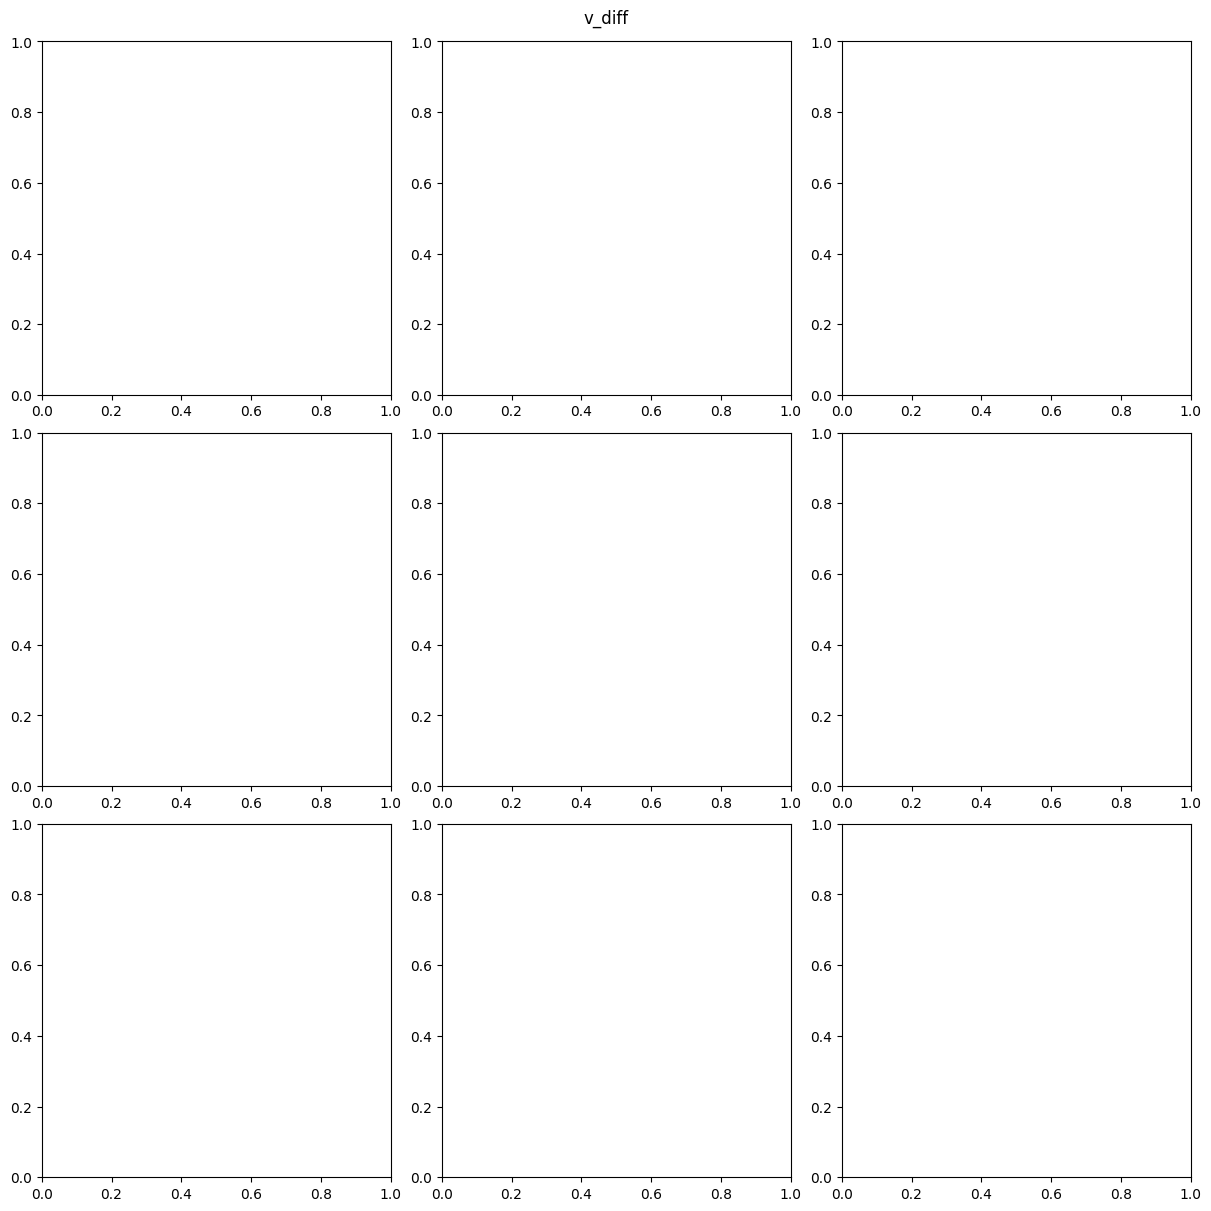

In [19]:
import matplotlib.ticker as mticker

def plot_single_heatmap(
    df: pl.DataFrame,
    landscape: str,
    l: int,
    value: str,
    ax,
    vmin: float = 0.0,
    vmax: float = 10.0,
    log_plot: bool = False,
    cmap: str = "plasma",
):
    """
    Plot a heatmap of `value` as a function of alphar (x) and K (y)
    for a given landscape and l.
    """

    # 1) Consistent filtering (alphar = 0 is removed at the source)
    df_heat = (
        df.filter(
            (pl.col("landscape") == landscape) &
            (pl.col("l") == l) &
            (pl.col("alphar") > 0)
        )
        .select(["alphar", "K", value])
        .sort(["K", "alphar"])
    )

    if df_heat.height == 0:
        ax.set_title(f"{landscape} -- l={l}\n(no data)")
        return None

    # 2) Pivot → the grid comes from the pivot (source of truth)
    pivot = df_heat.pivot(values=value, index="K", on="alphar", aggregate_function="mean")
    pivot = pivot.sort("K")

    Y = pivot["K"].to_numpy()
    X = np.sort(np.array([c for c in pivot.columns if c != "K"], dtype=float))
    Z2D = pivot.select([str(x) for x in X]).to_numpy()

    X_grid, Y_grid = np.meshgrid(X, Y)

    # 3) Scale (lin / log)
    if log_plot:
        Z2D = np.log2(Z2D)
        vmin, vmax = -2, 2
        label = rf"$\log_2({value})$"
    else:
        label = value
        if value == "v_mean":
            vmin, vmax = 0, 20
        elif value == "v_diff":
            vmin, vmax = 0, 10
        elif value == "v_ratio":
            vmin, vmax = 1, 2
    # ... (identique jusqu'au plot)

    # 3) Scale
    if log_plot:
        Z2D   = np.log2(Z2D)
        vmin, vmax = -2, 2
        label = rf"$\log_2({value})$"
    else:
        label = value

    # 4) Plot
    c = ax.pcolormesh(X_grid, Y_grid, Z2D, cmap=cmap, shading="auto", vmin=vmin, vmax=vmax)
    ax.set_title(f"{landscape} -- l={l}")
    ax.set_xlabel(r"$\alpha_r$")
    ax.set_ylabel(r"$K$")
    ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))
    return c



for value, vmin, vmax in [("v_mean", 0, 20), ("v_diff", -10, 10), ("v_ratio", 0, 3), ("wf", 0, 1)]:

    n_rows = len(landscapes)
    n_cols = len(ls)
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(4*n_cols, 4*n_rows), constrained_layout=True)
    axes_flat = axes.flatten() if axes.ndim > 1 else axes
    plt.suptitle(value)

    for ax, (landscape, l) in zip(axes_flat, product(landscapes, ls)):
        c = plot_single_heatmap(df_all, landscape, l, value, ax, vmin=vmin, vmax=vmax)

    fig.colorbar(c, ax=axes_flat, orientation='vertical', label=value)
    plt.show()

---- Observations ----

K joue un rôle plus important que alphar : on peut supposer que c'est la fréquence d'un repliement même léger qui jour un rôle plus important que son déroulement total

Plus le linker est petit plus la différence est importante : des facteurs de transcription efficaces en fréquences permettent à des chromatines denses d'être extrudées vite

Le remodellage aide plus dans les cas aléatoires que dans les cas périodiques

# .